<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo Final del Máster · Área 1 · Aula 1</p>
<p style="margin: 0; text-align:right;">20241 - Máster universitario en Ciencias de datos (<i>Data science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicaciones</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">    
	<strong>Estudiante:</strong> James Eward Humberstone Morales
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>El horizonte de predicción para cada clúster sea definido en función del ciclo de aprovisionamiento, entendido como la suma entre el intervalo entre pedidos y el tiempo de entrega (lead time). Se utilizó el valor de la mediana por clúster como estimación operativa, buscando un equilibrio entre la precisión y la aplicabilidad logística.</p>
</div>

In [1]:
!pip install pmdarima scikit_posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.8 MB/s eta 0:00:0000:0100:01


In [2]:
# Carga de librerías
import pandas as pd
import numpy as np
import random
import tensorflow as tf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,  mean_absolute_error
from keras.models import Sequential, save_model, load_model
from keras.layers import LSTM, Dense, Input
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
import keras_tuner as kt
from sklearn.model_selection import train_test_split
import joblib
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import scipy.stats as stats 
from scipy.stats import shapiro, levene, kruskal, kstest, norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from scipy.optimize import minimize_scalar
import scikit_posthocs as sp

2025-04-26 14:50:15.142601: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745679015.328755      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745679015.391990      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# -----------------------------
# Establecer semilla para reproducibilidad
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Preparación de los datos

In [13]:
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

In [14]:
# -----------------------------
# CARGAR Y FILTRAR DATOS
# -----------------------------
df_irregulares = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()

In [15]:
df_irregulares.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213744 entries, 26352 to 652943
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           213744 non-null  int64         
 1   idSecuencia        213744 non-null  datetime64[ns]
 2   bolOpen            213744 non-null  int64         
 3   bolHoliday         213744 non-null  int64         
 4   year               213744 non-null  int64         
 5   month              213744 non-null  int64         
 6   day                213744 non-null  int64         
 7   day_of_week        213744 non-null  int64         
 8   week_of_year       213744 non-null  int64         
 9   week_of_month      213744 non-null  int64         
 10  bolPromotion       213744 non-null  int64         
 11  udsVenta           213744 non-null  int64         
 12  median_venta       213744 non-null  int64         
 13  cv                 213744 non-null  float64  

In [7]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
target = "udsVenta"
exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta',
    'cv', 'outlier_rate', 'aprovisionamiento'
]
columnas_modelo = [target] + exogenas
n_lags = 18

In [8]:
# -----------------------------
# GENERAR SECUENCIAS MULTISERIE
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, df_prod in df_irregulares.groupby("producto"):
    df_prod = df_prod.sort_values("idSecuencia")
    
    if len(df_prod) <= n_lags:
        continue  # Saltar si la serie es muy corta

    datos = df_prod[columnas_modelo].copy()

    # Asegurar que aprovisionamiento es constante (replicado si hace falta)
    if "aprovisionamiento" in datos.columns:
        aprov_valor = datos["aprovisionamiento"].iloc[0]
        datos["aprovisionamiento"] = aprov_valor

    # Escalar individualmente
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # udsVenta

    productos_validos += 1

# -----------------------------
# CONVERTIR Y GUARDAR
# -----------------------------
X_total = np.array(X_total)
y_total = np.array(y_total)

np.save("X_lstm_irregulares.npy", X_total)
np.save("y_lstm_irregulares.npy", y_total)

# Guardar columnas usadas
joblib.dump(columnas_modelo, "columnas_modelo_lstm_irregulares.pkl")

print(f"Dataset generado con éxito")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset generado con éxito
Productos válidos: 292
X shape: (208488, 18, 11) | y shape: (208488,)


# 2. Generar Red LSTM

In [4]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_irregulares.npy")
y = np.load("/kaggle/working/y_lstm_irregulares.npy")

In [5]:
# -----------------------------
# CONSTRUIR MODELO PARA TUNING
# -----------------------------
def construir_modelo_lstm(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))  
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3])
        ),
        loss='mse'
    )
    return model

In [6]:
# -----------------------------
# CONFIGURAR KERASTUNER
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_general',
    project_name='lstm_multiserie1',
    seed=SEED
)

I0000 00:00:1745336948.163729      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
# -----------------------------
# ENTRENAMIENTO CON VALIDACIÓN
# -----------------------------
def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X, y,
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Trial 5 Complete [00h 13m 16s]
val_loss: 0.015965847298502922

Best val_loss So Far: 0.01590912975370884
Total elapsed time: 01h 28m 00s


In [8]:
# -----------------------------
# Obtener el mejor modelo y entrenar
# -----------------------------
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.fit(X, y, epochs=30, batch_size=best_hp.get('batch_size'), verbose=1)

Epoch 1/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - loss: 0.0168
Epoch 2/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0161
Epoch 3/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0160
Epoch 4/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0159
Epoch 5/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0159
Epoch 6/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0158
Epoch 7/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0158
Epoch 8/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0158
Epoch 9/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0157
Epoch 10/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0157
Epoch 11/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0157
Epoch 12/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0157
Epoch 13/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0157
Epoch 14/30
13031/13031 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - 

In [9]:
# Guardar modelo y parámetros
save_model(best_model, "modelo_lstm_general.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_general.pkl")

print("Entrenamiento completado. Modelo y parámetros guardados.")

Entrenamiento completado. Modelo y parámetros guardados.


## 2.1 Calcular la precisión de LSTM

In [10]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
columnas_modelo = joblib.load("/kaggle/working/columnas_modelo_lstm_irregulares.pkl")
target = columnas_modelo[0]
exogenas = columnas_modelo[1:]
n_lags = 18

In [11]:
# -----------------------------
# CARGAR MODELO LSTM GENERAL
# -----------------------------
modelo = load_model("/kaggle/working/modelo_lstm_general.h5", compile=False)

In [12]:
# -----------------------------
# FUNCIONES
# -----------------------------
def preparar_X_pred(df_producto, columnas, n_lags):
    df_producto = df_producto.sort_values("idSecuencia")
    datos = df_producto[columnas].copy()

    # Replicar aprovisionamiento si es constante
    if "aprovisionamiento" in datos.columns:
        datos["aprovisionamiento"] = datos["aprovisionamiento"].iloc[0]

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    if len(datos_scaled) <= n_lags:
        return None, None, None, None

    X_pred = [datos_scaled[i - n_lags:i] for i in range(n_lags, len(datos_scaled))]
    fechas = df_producto["idSecuencia"].iloc[n_lags:].values
    y_real = df_producto[target].iloc[n_lags:].values

    return np.array(X_pred), fechas, y_real, scaler

def desescalar_predicciones(pred_scaled, scaler, n_exogenas):
    datos_completos = np.concatenate(
        [pred_scaled, np.zeros((len(pred_scaled), n_exogenas))], axis=1
    )
    return scaler.inverse_transform(datos_completos)[:, 0]

In [16]:
# -----------------------------
# PREDICCIÓN PARA TODAS LAS SERIES
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_irregulares['producto'].unique()

resultados = []

for producto_id, df_producto in tqdm(df_irregulares.groupby("producto")):
    X_pred, fechas, y_real, scaler_local = preparar_X_pred(df_producto, columnas_modelo, n_lags)
    if X_pred is None:
        continue

    y_pred_scaled = modelo.predict(X_pred, verbose=0)
    y_pred = desescalar_predicciones(y_pred_scaled, scaler_local, len(exogenas))

    df_resultado = pd.DataFrame({
        'producto': producto_id,
        'fecha': fechas,
        'valor_real': y_real,
        'valor_predicho': y_pred,
        'metodo': 'LSTM'
    })
    resultados.append(df_resultado)

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 292/292 [00:29<00:00,  9.86it/s]


 Predicciones finalizadas en 29.75 segundos.


In [17]:
# Concatenar resultados y exportar
df_predicciones_lstm_general = pd.concat(resultados, ignore_index=True)
df_predicciones_lstm_general.to_csv("predicciones_lstm_general.csv", index=False)

## 2.2 Visualizaciones

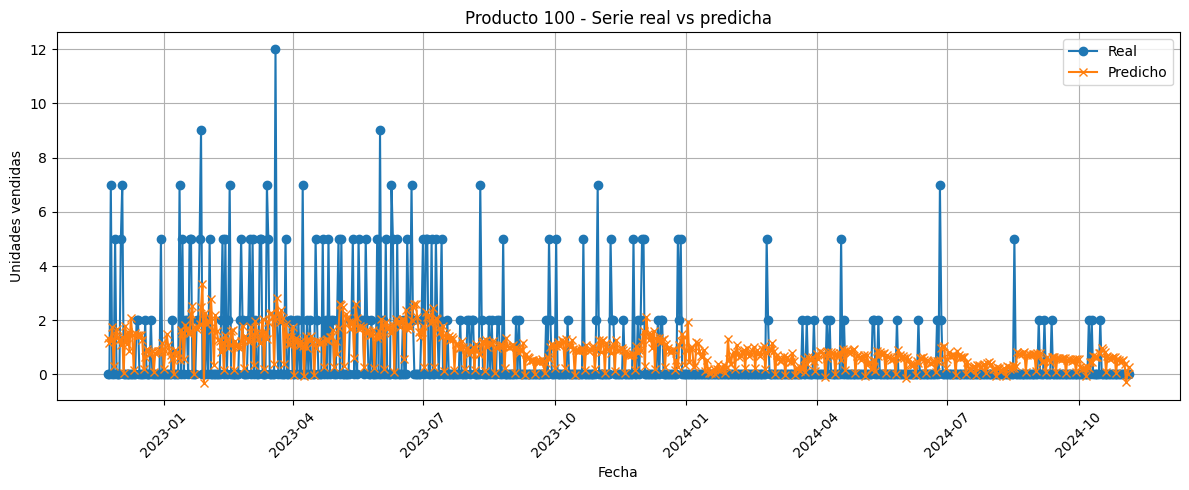

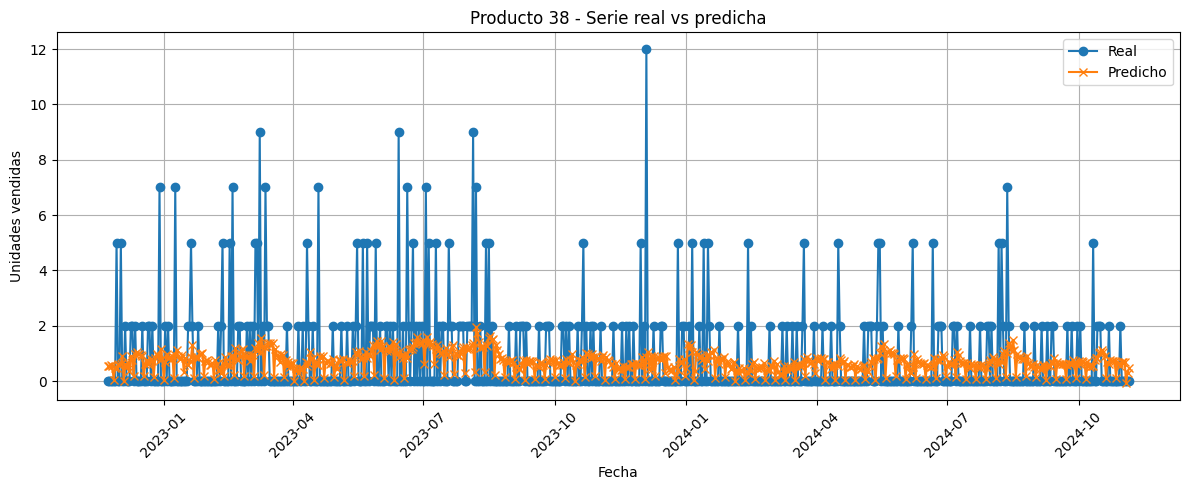

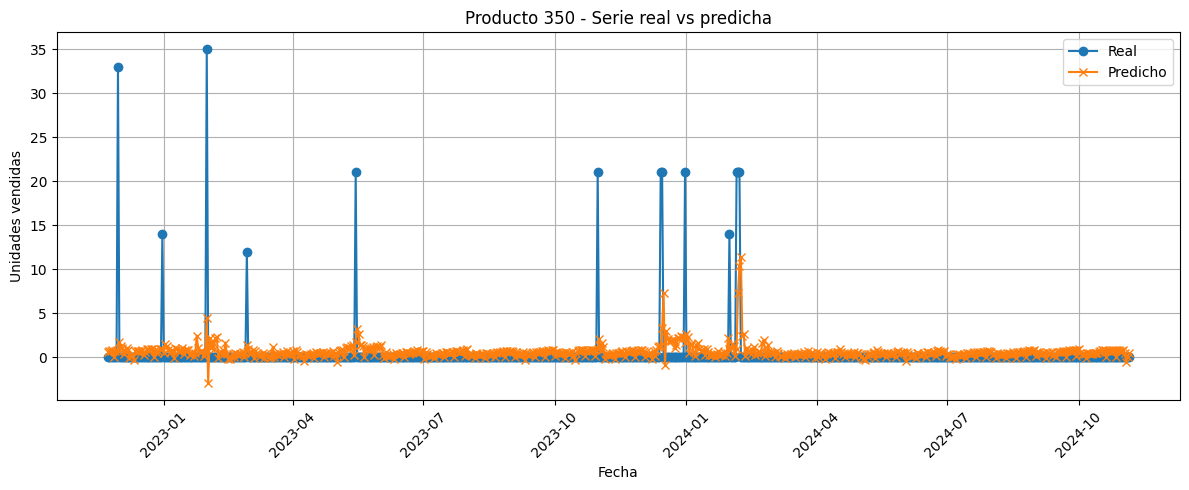

In [18]:
productos_ejemplo = [100, 38, 350]

for producto_id in productos_ejemplo:
    df_prod = df_predicciones_lstm_general[df_predicciones_lstm_general['producto'] == producto_id]
    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_producto_{producto_id}.png")
    plt.show()

In [19]:
# Calcular RMSE por producto
rmse_por_producto = (
    df_predicciones_lstm_general[['producto', 'valor_real', 'valor_predicho']]
    .groupby("producto")[['valor_real', 'valor_predicho']]
    .apply(lambda g: np.sqrt(np.mean((g['valor_real'] - g['valor_predicho']) ** 2)))
    .reset_index(name="RMSE")
)

print(rmse_por_producto.describe())

         producto        RMSE
count  292.000000  292.000000
mean   628.232877    1.958361
std    250.370201    1.678380
min     38.000000    0.770314
25%    447.500000    1.365839
50%    663.500000    1.671659
75%    834.250000    2.026499
max    998.000000   25.165289


In [20]:
# RMSE global
rmse_global = np.sqrt(np.mean((df_predicciones_lstm_general['valor_real'] - df_predicciones_lstm_general['valor_predicho']) ** 2))
print(f"RMSE global del modelo LSTM generalizado: {rmse_global:.4f}")

RMSE global del modelo LSTM generalizado: 2.5773


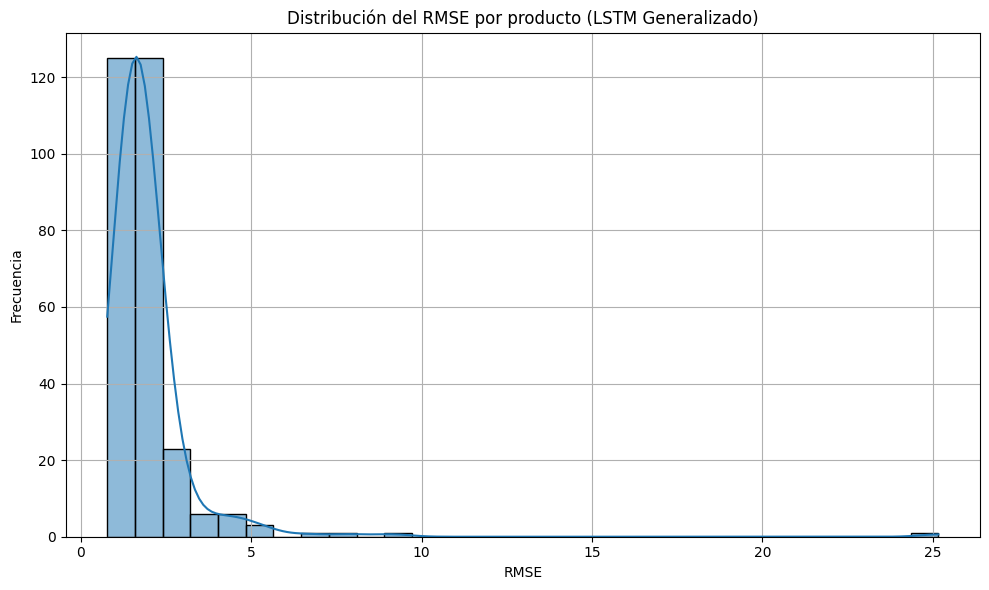

In [21]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(10, 6))
sns.histplot(rmse_por_producto['RMSE'], bins=30, kde=True)
plt.title("Distribución del RMSE por producto (LSTM Generalizado)")
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.savefig("histograma_rmse_lstm.png")
plt.show()

# 3. Aplicar el modelo ARIMA

In [23]:
df_irregulares.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213744 entries, 26352 to 652943
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           213744 non-null  int64         
 1   idSecuencia        213744 non-null  datetime64[ns]
 2   bolOpen            213744 non-null  int64         
 3   bolHoliday         213744 non-null  int64         
 4   year               213744 non-null  int64         
 5   month              213744 non-null  int64         
 6   day                213744 non-null  int64         
 7   day_of_week        213744 non-null  int64         
 8   week_of_year       213744 non-null  int64         
 9   week_of_month      213744 non-null  int64         
 10  bolPromotion       213744 non-null  int64         
 11  udsVenta           213744 non-null  int64         
 12  median_venta       213744 non-null  int64         
 13  cv                 213744 non-null  float64  

In [24]:
# -----------------------------
# Configuración
# -----------------------------
n_test = 18  # horizonte de predicción
col_serie = "udsVenta"

In [25]:
# -----------------------------
# Función para ajustar ARIMA por producto
# -----------------------------
def ajustar_arima_producto(df_producto, col_serie="udsVenta", n_test=18):
    df_producto = df_producto.sort_values("idSecuencia")
    serie = df_producto[col_serie].values

    if len(serie) <= n_test + 10:
        return None  # muy corta para entrenar

    try:
        # 1. Determinar orden ARIMA automáticamente
        modelo_auto = auto_arima(serie[:-n_test], seasonal=False,
                                 error_action='ignore', suppress_warnings=True,
                                 max_p=5, max_q=5, max_d=2, stepwise=True)
        orden = modelo_auto.order

        # 2. Ajustar ARIMA final
        modelo = ARIMA(serie[:-n_test], order=orden)
        modelo_fit = modelo.fit()

        # 3. Predecir y calcular residuos
        y_pred = modelo_fit.predict(start=len(serie) - n_test, end=len(serie) - 1)
        y_real = serie[-n_test:]
        residuos = y_real - y_pred

        return {
            "orden": orden,
            "y_pred": y_pred,
            "residuos": residuos,
            "y_real": y_real,
            "modelo_fit": modelo_fit
        }

    except Exception as e:
        print(f"Error en producto {df_producto['producto'].iloc[0]}: {e}")
        return None

In [26]:
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters")
warnings.simplefilter("ignore", ConvergenceWarning)

In [27]:
# -----------------------------
# Aplicar a todos los productos regulares
# -----------------------------

# Inicializar timer y barra de progreso
inicio = time.time()
productos = df_irregulares['producto'].unique()

resultados_arima = {}
for producto_id, df_prod in tqdm(df_irregulares.groupby("producto")):
    resultado = ajustar_arima_producto(df_prod, col_serie=col_serie, n_test=n_test)
    if resultado is not None:
        resultados_arima[producto_id] = resultado

fin = time.time()
tiempo_total = fin - inicio
print(f"\n Predicciones finalizadas en {tiempo_total:.2f} segundos.")

100%|██████████| 292/292 [26:37<00:00,  5.47s/it]


 Predicciones finalizadas en 1597.31 segundos.


In [28]:
# -----------------------------
# Guardar resultados
# -----------------------------
joblib.dump(resultados_arima, "resultados_arima_292.pkl")
print(f"ARIMA ajustado para {len(resultados_arima)} productos.")

ARIMA ajustado para 292 productos.


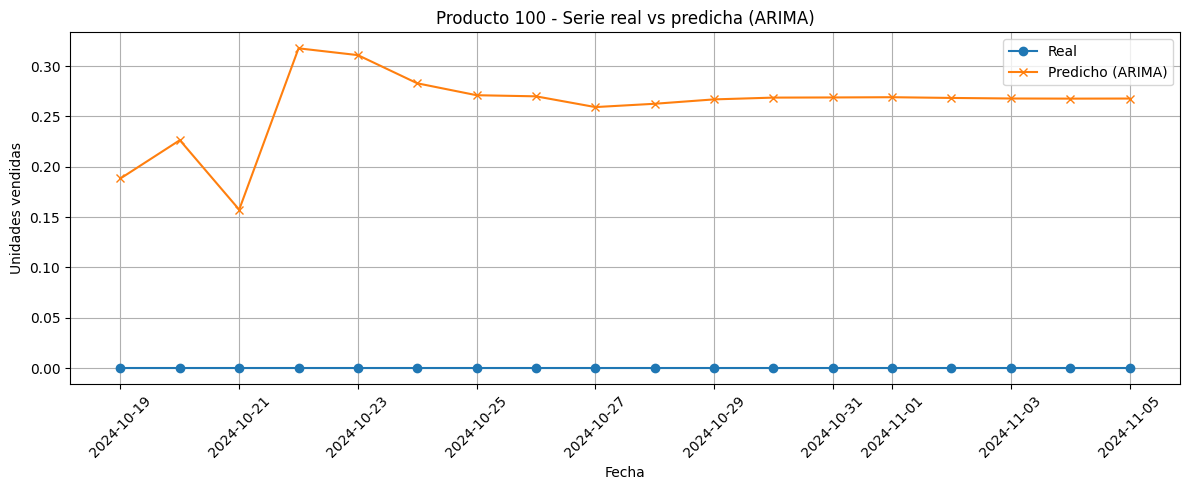

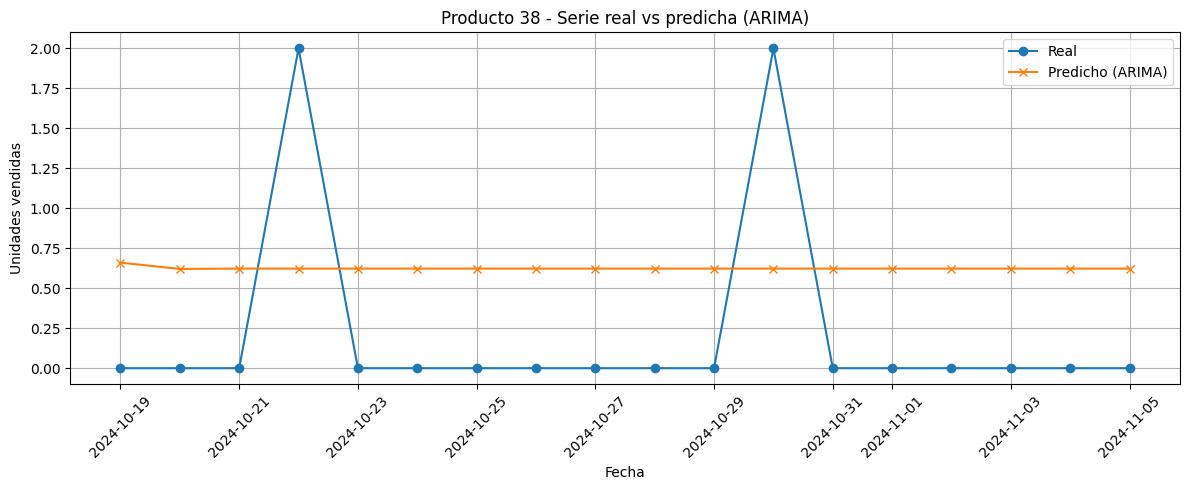

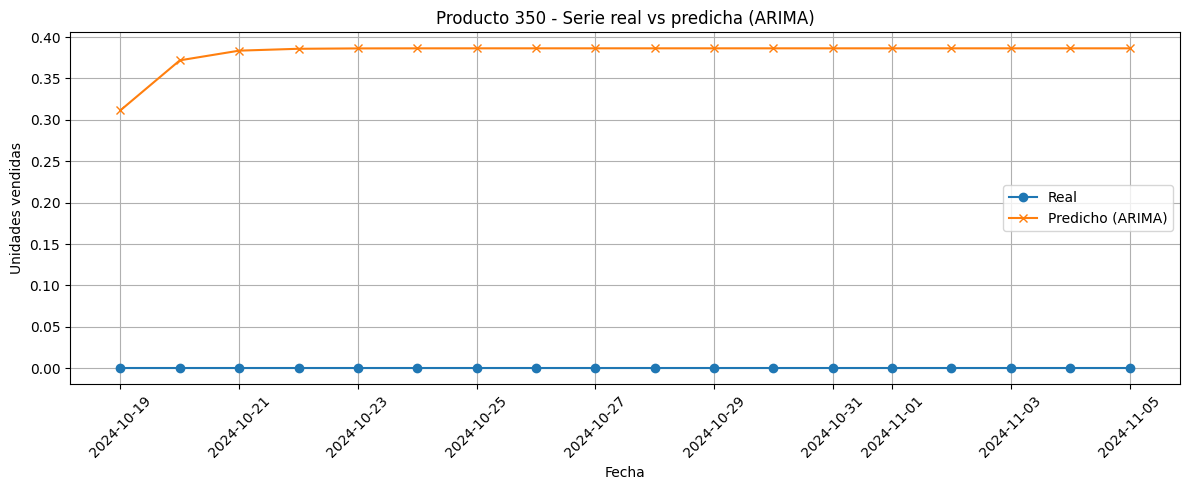

In [29]:
productos_ejemplo = [100, 38, 350] 

for producto_id in productos_ejemplo:
    resultado = resultados_arima[producto_id]
    
    y_real = resultado["y_real"]
    y_pred = resultado["y_pred"]
    
    
    # Verificar si hay datos del producto en el DataFrame
    df_producto = df_irregulares[df_irregulares['producto'] == producto_id].copy()

    if not df_producto.empty:
        fechas_disponibles = df_producto['idSecuencia'].reset_index(drop=True)
        # Ajustamos el número de fechas a la longitud de y_real
        if len(fechas_disponibles) >= len(y_real):
            fechas = fechas_disponibles.iloc[-len(y_real):].reset_index(drop=True)
        else:
            raise ValueError(f"El número de fechas disponibles ({len(fechas_disponibles)}) es menor que la longitud de y_real ({len(y_real)}) para el producto {producto_id}")
    else:
        raise ValueError(f"No se encontraron datos en df_regulares para el producto {producto_id}")

    # Crear DataFrame para trazado
    df_plot = pd.DataFrame({
        'fecha': fechas,
        'Real': y_real,
        'Predicho': y_pred
    })

    # Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot['fecha'], df_plot['Real'], label='Real', marker='o')
    plt.plot(df_plot['fecha'], df_plot['Predicho'], label='Predicho (ARIMA)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (ARIMA)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_arima_producto_{producto_id}.png")
    plt.show()

# 4. Modelo híbrido paralelo

In [30]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [31]:
# --- Cargar base original para obtener fechas ---
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

# Asegurarnos que las fechas estén ordenadas por producto y por secuencia
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [32]:
# --- Cargar predicciones LSTM ---
df_lstm = pd.read_csv("/kaggle/working/predicciones_lstm_general.csv")

In [33]:
# Crear diccionario para fechas por producto (últimos N puntos según cada serie ARIMA)
fechas_por_producto = {}
for producto_id in resultados_arima.keys():
    n_puntos = len(resultados_arima[producto_id]["y_real"])
    fechas = df_base[df_base["producto"] == producto_id]["idSecuencia"].iloc[-n_puntos:].reset_index(drop=True)
    fechas_por_producto[producto_id] = fechas

In [34]:
# --- Calcular combinación ponderada ARIMA + LSTM ---
resultados_paralelo_ponderado = []

for producto_id in resultados_arima.keys():
    arima_data = resultados_arima[producto_id]
    y_pred_arima = np.array(arima_data["y_pred"])
    y_real = np.array(arima_data["y_real"])

    # Obtener fechas correspondientes
    fechas = fechas_por_producto[producto_id]

    # LSTM: filtrar y alinear
    df_lstm_prod = df_lstm[df_lstm['producto'] == producto_id].copy()
    if len(df_lstm_prod) >= len(y_pred_arima):
        y_pred_lstm = df_lstm_prod['valor_predicho'].values[-len(y_pred_arima):]
        y_real_lstm = df_lstm_prod['valor_real'].values[-len(y_pred_arima):]

        # Verificación (opcional)
        if not np.allclose(y_real, y_real_lstm):
            print(f"[!] Warning: diferencias en y_real para producto {producto_id}, se usará y_real de ARIMA.")

        # --- Optimizar peso ---
        def calcular_rmse_ponderado(w_arima, y_arima, y_lstm, y_real):
            y_comb = w_arima * y_arima + (1 - w_arima) * y_lstm
            return mean_squared_error(y_real, y_comb, squared=False)

        resultado = minimize_scalar(
            calcular_rmse_ponderado,
            bounds=(0, 1),
            args=(y_pred_arima, y_pred_lstm, y_real),
            method='bounded'
        )

        w_optimo = resultado.x
        rmse_optimo = resultado.fun
        y_comb = w_optimo * y_pred_arima + (1 - w_optimo) * y_pred_lstm
        mae = mean_absolute_error(y_real, y_comb)
        mape = np.mean(np.abs((y_real - y_comb) / np.maximum(y_real, 1))) * 100

        # Guardar resultados
        for fecha, real, pred in zip(fechas, y_real, y_comb):
            resultados_paralelo_ponderado.append({
                "producto": producto_id,
                "fecha": fecha,
                "valor_real": real,
                "valor_predicho": pred,
                "w_arima": round(w_optimo, 3),
                "w_lstm": round(1 - w_optimo, 3),
                "rmse": rmse_optimo,
                "mae": mae,
                "mape": mape,
                "modelo": "paralelo_ponderado"
            })
    else:
        print(f"LSTM no tiene suficientes datos para producto {producto_id}")

# Convertir a DataFrame
df_resultados_paralelo_ponderado = pd.DataFrame(resultados_paralelo_ponderado)

In [35]:
df_resultados_paralelo_ponderado.head()

,producto,fecha,valor_real,valor_predicho,w_arima,w_lstm,rmse,mae,mape,modelo
0,38,2024-10-19,0,0.783456,0.487,0.513,0.734164,0.675663,59.835115,paralelo_ponderado
1,38,2024-10-20,0,0.356151,0.487,0.513,0.734164,0.675663,59.835115,paralelo_ponderado
2,38,2024-10-21,0,0.655313,0.487,0.513,0.734164,0.675663,59.835115,paralelo_ponderado
3,38,2024-10-22,2,0.625110,0.487,0.513,0.734164,0.675663,59.835115,paralelo_ponderado
4,38,2024-10-23,0,0.686636,0.487,0.513,0.734164,0.675663,59.835115,paralelo_ponderado


In [36]:
df_resultados_paralelo_ponderado.to_csv("predicciones_ponderado.csv", index=False)

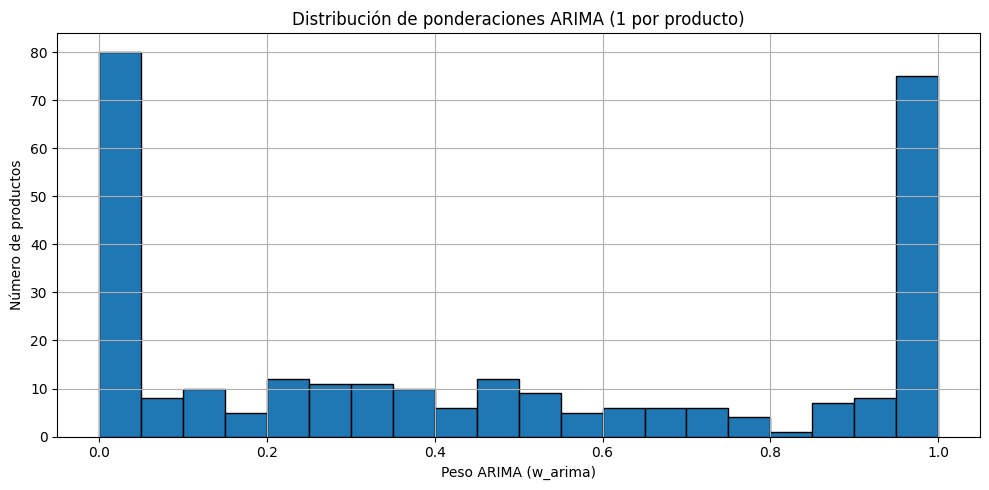

In [37]:
df_pesos_unicos = df_resultados_paralelo_ponderado.drop_duplicates(subset="producto")


plt.figure(figsize=(10, 5))
plt.hist(df_pesos_unicos["w_arima"], bins=20, edgecolor='black')
plt.title("Distribución de ponderaciones ARIMA (1 por producto)")
plt.xlabel("Peso ARIMA (w_arima)")
plt.ylabel("Número de productos")
plt.grid(True)
plt.tight_layout()
plt.show()

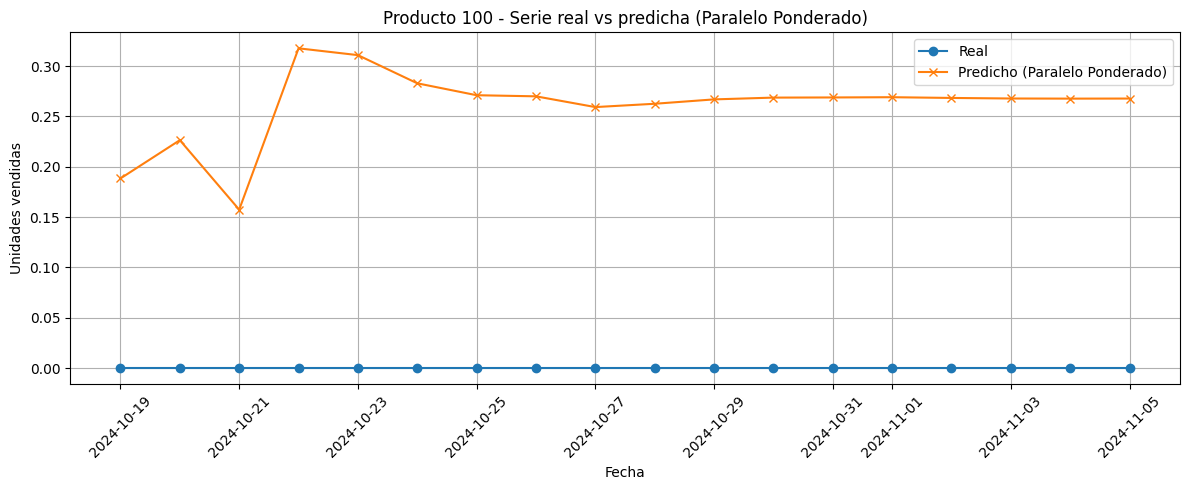

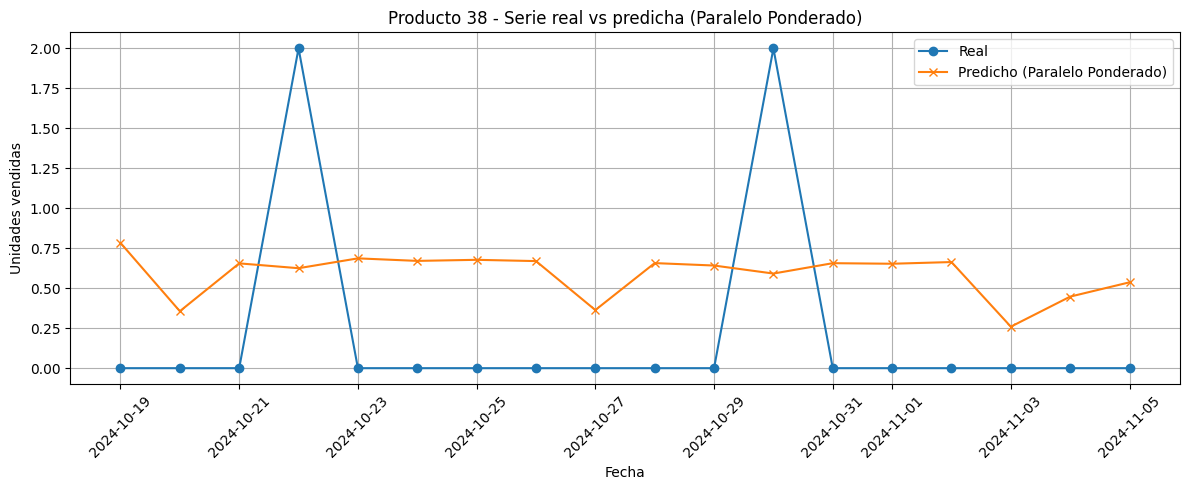

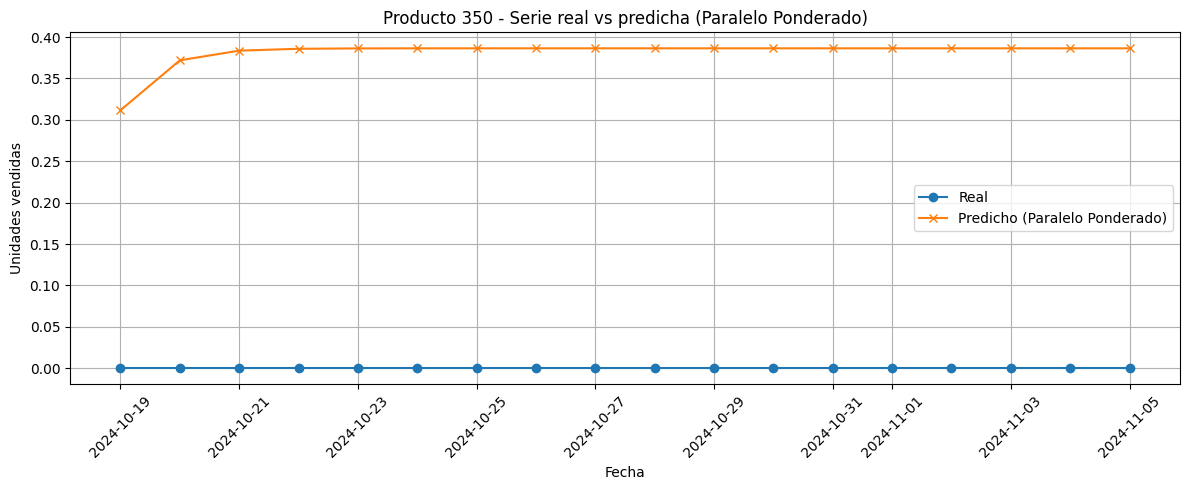

In [38]:
productos_ejemplo = [100, 38, 350]

for producto_id in productos_ejemplo:
    df_prod = df_resultados_paralelo_ponderado[df_resultados_paralelo_ponderado['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Paralelo Ponderado)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Paralelo Ponderado)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_paralelo_ponderado_producto_{producto_id}.png")
    plt.show()

# 5. Modelo híbrido secuencial

In [4]:
# -----------------------------
# PARÁMETROS
# -----------------------------
n_lags = 1  # número de pasos para la secuencia
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_objetivo = 'residuo'
columnas_modelo = [columna_objetivo] + columnas_exogenas

In [ ]:
# --- Cargar base original para obtener fechas ---
df = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

df_base = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()

df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

## 5.1 Cargar predicciones y residuos de ARIMA

In [6]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [7]:
productos_base = set(df_base['producto'].unique())
productos_arima = set(resultados_arima.keys())
productos_comunes = productos_base & productos_arima

print(f"Productos comunes: {len(productos_comunes)}")

Productos comunes: 292


In [8]:
# -----------------------------
# CREAR DATASET MULTISERIE CON RESIDUOS
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred

    # Extraer las 18 filas correspondientes en base original
    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) < n_lags:
        continue  # no se puede formar ni una secuencia

    df_prod["residuo"] = residuos

    # Mantener aprovisionamiento constante si aplica
    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    # Escalar por producto
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    # Rolling window para los 18 puntos
    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # residuo_t

    productos_validos += 1

In [9]:
X_total = np.array(X_total)
y_total = np.array(y_total)

# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
np.save("X_lstm_residuos_rolling.npy", X_total)
np.save("y_lstm_residuos_rolling.npy", y_total)
joblib.dump(columnas_modelo, "columnas_modelo_residuos.pkl")

['columnas_modelo_residuos.pkl']

In [10]:
# Reporte
print(f"Dataset generado exitosamente")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset generado exitosamente
Productos válidos: 292
X shape: (4964, 1, 11) | y shape: (4964,)


## 5.2 Aplicar red LSTM sobre residuos

In [11]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_residuos_rolling.npy")
y = np.load("/kaggle/working/y_lstm_residuos_rolling.npy")

In [12]:
# -----------------------------
# DIVISIÓN TRAIN/VALIDACIÓN
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)

In [13]:
# -----------------------------
# DEFINIR FUNCIÓN DE MODELO
# -----------------------------
def construir_modelo_lstm(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))

    # Unidades en LSTM
    units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(LSTM(units=units, activation='tanh'))
    model.add(Dense(1))

    # Tasa de aprendizaje
    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=MeanSquaredError(), metrics=['mae'])
    return model

In [14]:
# -----------------------------
# CONFIGURAR RANDOM SEARCH
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_residuos',
    project_name='lstm_residuos_n1',
    seed=SEED
)

I0000 00:00:1745463491.966237      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [15]:
# -----------------------------
# ENTRENAMIENTO DEL TUNER
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 01m 07s]
val_loss: 0.09705538302659988

Best val_loss So Far: 0.09645403921604156
Total elapsed time: 00h 05m 35s


In [16]:
# -----------------------------
# EXTRAER MEJORES PARÁMETROS
# -----------------------------
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("🔎 Mejores hiperparámetros encontrados:")
print(f"Units: {best_hp.get('units')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")

🔎 Mejores hiperparámetros encontrados:
Units: 32
Learning Rate: 0.005977728042983696


In [17]:
# -----------------------------
# ENTRENAR MODELO FINAL
# -----------------------------
modelo_final = tuner.hypermodel.build(best_hp)

modelo_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_hp.get('batch_size'),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1078 - mae: 0.2441 - val_loss: 0.0985 - val_mae: 0.2432
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1052 - mae: 0.2413 - val_loss: 0.0987 - val_mae: 0.2467
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1048 - mae: 0.2420 - val_loss: 0.0983 - val_mae: 0.2449
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1045 - mae: 0.2422 - val_loss: 0.0980 - val_mae: 0.2425
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1043 - mae: 0.2423 - val_loss: 0.0977 - val_mae: 0.2401
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1042 - mae: 0.2422 - val_loss: 0.0976 - val_mae: 0.2382
Epoch 7/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1041 - mae: 0.2421 - val_loss: 0.0975 - val_mae: 0.2368
Epoch 8/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1040 - mae: 0.2420 - val_loss: 0.0974 - val_mae: 0.2357
Epoch 9/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [18]:
# -----------------------------
# GUARDAR MODELO FINAL
# -----------------------------
modelo_final.save("modelo_lstm_residuos_n1_tuned.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_residuos.pkl")
print("Modelo LSTM (residuos) entrenado y guardado")

Modelo LSTM (residuos) entrenado y guardado


## 5.3 Cálculo de residuos

In [19]:
# -----------------------------
# CARGAR RECURSOS NECESARIOS
# -----------------------------
# Modelo entrenado
modelo_lstm = load_model("/kaggle/working/modelo_lstm_residuos_n1_tuned.h5")

# Columnas del modelo
columnas_modelo = joblib.load("/kaggle/working/columnas_modelo_residuos.pkl")

In [20]:
# Resultados ARIMA
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [21]:
# Dataset original base
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")

df_base = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()

df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [22]:
# -----------------------------
# PARÁMETROS DEL MODELO
# -----------------------------
n_lags = 1

In [23]:
# -----------------------------
# GENERAR PREDICCIONES SEC. HÍBRIDO
# -----------------------------
resultados_secuencial = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred_arima = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred_arima

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["residuo"] = residuos
    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"[!] Producto {producto_id} omitido por columnas faltantes: {e}")
        continue

    # Escalar datos
    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    fechas = df_prod["idSecuencia"].iloc[n_lags:].reset_index(drop=True)
    y_real_final = y_real[n_lags:]
    y_pred_arima_final = y_pred_arima[n_lags:]

    for i in range(n_lags, len(datos_scaled)):
        X_input = datos_scaled[i - n_lags:i].reshape(1, n_lags, len(columnas_modelo))
        pred_residuo = modelo_lstm.predict(X_input, verbose=0)[0][0]
        y_pred_hibrido = y_pred_arima[i] + pred_residuo

        resultados_secuencial.append({
            "producto": producto_id,
            "fecha": fechas[i - n_lags],
            "valor_real": y_real[i],
            "valor_predicho": y_pred_hibrido,
            "modelo": "secuencial"
        })

In [24]:
# Convertir a DataFrame
df_resultados_secuencial = pd.DataFrame(resultados_secuencial)

In [25]:
# Calcular métricas por producto
metricas = df_resultados_secuencial.groupby("producto")[["valor_real", "valor_predicho"]].apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    })
).reset_index()



# Unir métricas al resultado
df_resultados_secuencial = df_resultados_secuencial.merge(metricas, on="producto")

In [26]:
df_resultados_secuencial.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,38,2024-10-20,0,0.705907,secuencial,0.863508,0.85018,77.885082
1,38,2024-10-21,0,0.834427,secuencial,0.863508,0.85018,77.885082
2,38,2024-10-22,2,0.752335,secuencial,0.863508,0.85018,77.885082
3,38,2024-10-23,0,0.969836,secuencial,0.863508,0.85018,77.885082
4,38,2024-10-24,0,0.808047,secuencial,0.863508,0.85018,77.885082


In [27]:
df_resultados_secuencial.to_csv("predicciones_secuencial.csv", index=False)

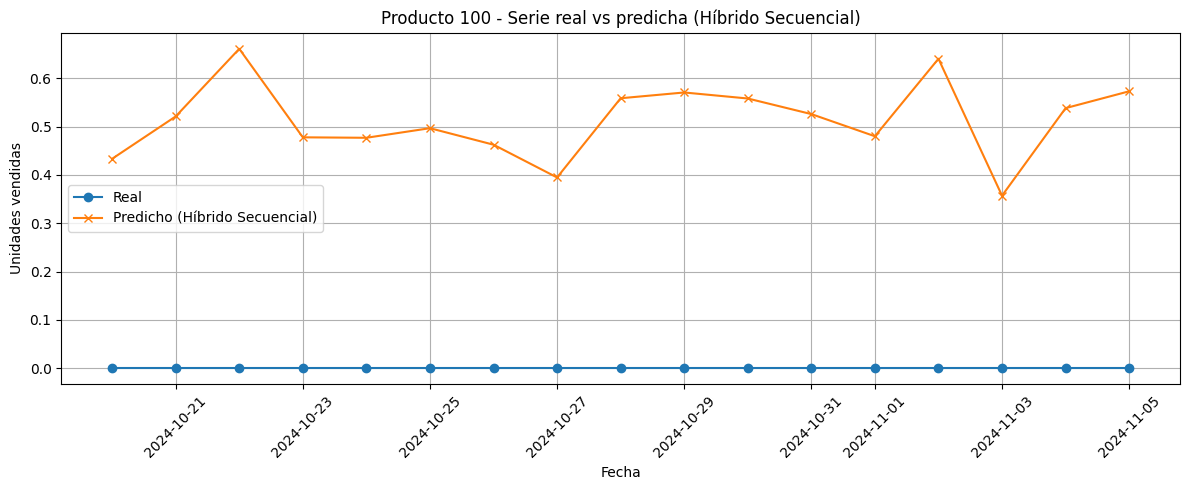

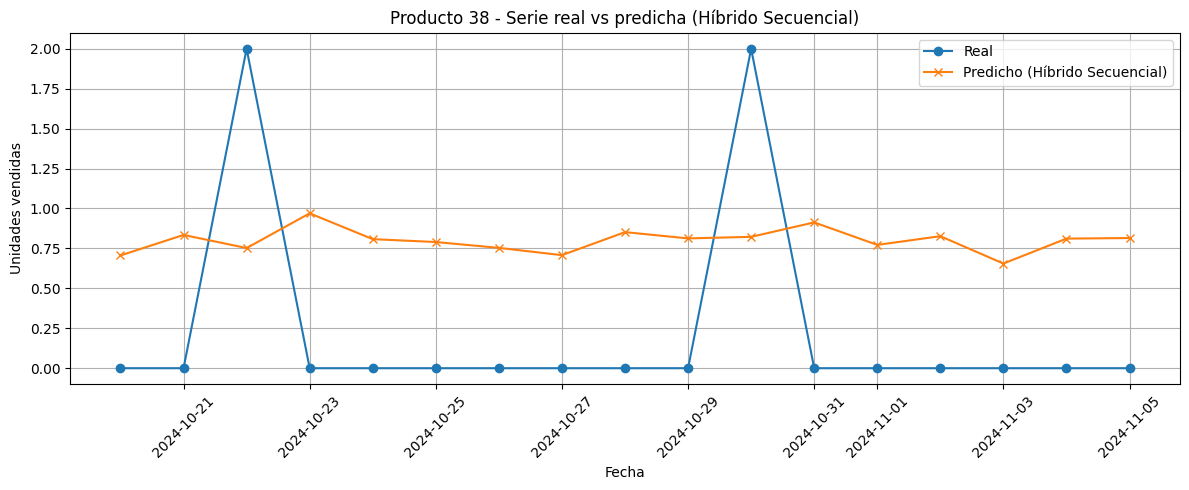

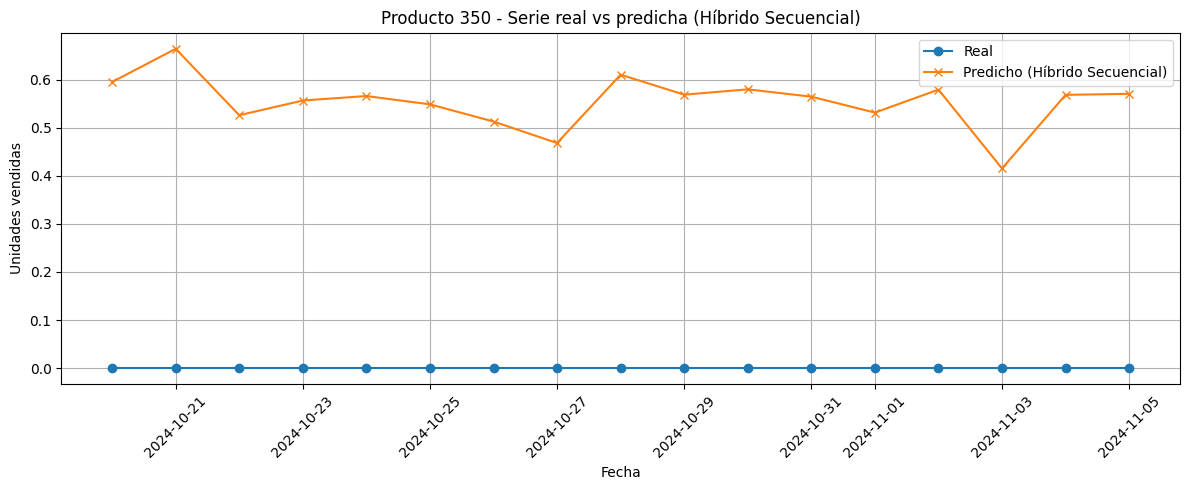

In [28]:
productos_ejemplo = [100, 38, 350] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_secuencial[df_resultados_secuencial['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Híbrido Secuencial)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Híbrido Secuencial)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_secuencial_producto_{producto_id}.png")
    plt.show()

# 6. Modelo híbrido integrado

In [29]:
# -----------------------------
# PARÁMETROS
# -----------------------------
n_lags = 1
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_arima = 'y_pred_arima'
columna_residuo = 'residuo_arima'
columna_objetivo = 'udsVenta'
columnas_modelo = [columna_objetivo] + [columna_arima, columna_residuo] + columnas_exogenas

In [30]:
# Cargar base
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [32]:
# Cargar predicciones ARIMA
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [33]:
# -----------------------------
# GENERAR SECUENCIAS MULTIVARIADAS
# -----------------------------
X_total = []
y_total = []
productos_validos = 0

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["udsVenta"] = y_real
    df_prod["y_pred_arima"] = y_pred
    df_prod["residuo_arima"] = residuos

    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    for i in range(n_lags, len(datos_scaled)):
        X_total.append(datos_scaled[i - n_lags:i])
        y_total.append(datos_scaled[i][0])  # objetivo: udsVenta

    productos_validos += 1

In [34]:
# Convertir a arrays
X_total = np.array(X_total)
y_total = np.array(y_total)

In [35]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
np.save("X_lstm_integrado.npy", X_total)
np.save("y_lstm_integrado.npy", y_total)
joblib.dump(columnas_modelo, "columnas_modelo_integrado.pkl")

['columnas_modelo_integrado.pkl']

In [36]:
print("Dataset para modelo híbrido integrado generado con éxito")
print(f"Productos válidos: {productos_validos}")
print(f"X shape: {X_total.shape} | y shape: {y_total.shape}")

Dataset para modelo híbrido integrado generado con éxito
Productos válidos: 292
X shape: (4964, 1, 13) | y shape: (4964,)


## 6.2 Entrenamiento de LSTM

In [37]:
# -----------------------------
# CARGAR DATOS
# -----------------------------
X = np.load("/kaggle/working/X_lstm_integrado.npy")
y = np.load("/kaggle/working/y_lstm_integrado.npy")

In [38]:
# -----------------------------
# DIVISIÓN TRAIN/VALIDACIÓN
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, shuffle=True
)

In [39]:
# -----------------------------
# DEFINIR FUNCIÓN DE MODELO
# -----------------------------
def construir_modelo_lstm_integrado(hp):
    model = Sequential()
    model.add(Input(shape=(X.shape[1], X.shape[2])))

    units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(LSTM(units=units, activation='tanh'))
    model.add(Dense(1))

    learning_rate = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=MeanSquaredError(), metrics=['mae'])
    return model

In [40]:
# -----------------------------
# CONFIGURAR RANDOM SEARCH
# -----------------------------
tuner = kt.RandomSearch(
    construir_modelo_lstm_integrado,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_lstm_integrado',
    project_name='lstm_integrado_n2',
    seed=SEED
)

In [41]:
# -----------------------------
# ENTRENAMIENTO DEL TUNER
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def get_batch_size(hp):
    return hp.Choice('batch_size', values=[8, 16, 32])

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=get_batch_size(tuner.oracle.hyperparameters),
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 01m 09s]
val_loss: 0.09688233584165573

Best val_loss So Far: 0.09600121527910233
Total elapsed time: 00h 05m 36s


In [42]:
# -----------------------------
# EXTRAER MEJORES PARÁMETROS
# -----------------------------
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("🔎 Mejores hiperparámetros encontrados:")
print(f"Units: {best_hp.get('units')}")
print(f"Learning Rate: {best_hp.get('learning_rate')}")

🔎 Mejores hiperparámetros encontrados:
Units: 16
Learning Rate: 0.00905127409782462


In [43]:
# -----------------------------
# ENTRENAR MODELO FINAL
# -----------------------------
modelo_final = tuner.hypermodel.build(best_hp)

modelo_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_hp.get('batch_size'),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1080 - mae: 0.2362 - val_loss: 0.0992 - val_mae: 0.2425
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1046 - mae: 0.2335 - val_loss: 0.0989 - val_mae: 0.2418
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1042 - mae: 0.2343 - val_loss: 0.0987 - val_mae: 0.2397
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1040 - mae: 0.2346 - val_loss: 0.0987 - val_mae: 0.2380
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1039 - mae: 0.2347 - val_loss: 0.0987 - val_mae: 0.2370
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1039 - mae: 0.2348 - val_loss: 0.0986 - val_mae: 0.2362
Epoch 7/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1038 - mae: 0.2348 - val_loss: 0.0986 - val_mae: 0.2356
Epoch 8/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1038 - mae: 0.2348 - val_loss: 0.0986 - val_mae: 0.2350
Epoch 9/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [44]:
# -----------------------------
# GUARDAR MODELO FINAL
# -----------------------------
modelo_final.save("modelo_lstm_integrado_n1_tuned.h5", include_optimizer=False)
joblib.dump(best_hp.values, "hiperparametros_lstm_integrado.pkl")
print("Modelo LSTM híbrido integrado guardado")

Modelo LSTM híbrido integrado guardado


## 6.3 Cálculo de la demanda

In [45]:
# -----------------------------
# CARGAR MODELO ENTRENADO
# -----------------------------
modelo_integrado = load_model("modelo_lstm_integrado_n1_tuned.h5")

In [46]:
# Cargar base
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [48]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [49]:
# -----------------------------
# CONFIGURACIÓN
# -----------------------------
columnas_exogenas = [
    'bolOpen', 'bolHoliday', 'bolPromotion', 'day_of_week',
    'week_of_year', 'week_of_month', 'median_venta', 'cv',
    'outlier_rate', 'aprovisionamiento'
]
columna_objetivo = 'udsVenta'
columnas_modelo = [columna_objetivo, 'y_pred_arima', 'residuo_arima'] + columnas_exogenas
n_lags = 1

In [50]:
# -----------------------------
# PREDECIR 17 PUNTOS POR PRODUCTO
# -----------------------------
resultados_integrado = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred_arima = np.array(datos_arima["y_pred"])
    residuos = y_real - y_pred_arima

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    if len(df_prod) <= n_lags:
        continue

    df_prod["udsVenta"] = y_real
    df_prod["y_pred_arima"] = y_pred_arima
    df_prod["residuo_arima"] = residuos

    if "aprovisionamiento" in df_prod.columns:
        df_prod["aprovisionamiento"] = df_prod["aprovisionamiento"].iloc[0]

    try:
        datos = df_prod[columnas_modelo].copy()
    except KeyError as e:
        print(f"Producto {producto_id}: columnas faltantes {e}")
        continue

    scaler = MinMaxScaler()
    datos_scaled = scaler.fit_transform(datos)

    fechas = df_prod["idSecuencia"].values[n_lags:]
    reales = datos.values[n_lags:, 0]

    for i in range(n_lags, len(datos_scaled)):
        X_input = datos_scaled[i - n_lags:i].reshape(1, n_lags, len(columnas_modelo))
        y_pred = modelo_integrado.predict(X_input, verbose=0)[0][0]

        resultados_integrado.append({
            "producto": producto_id,
            "fecha": fechas[i - n_lags],
            "valor_real": reales[i - n_lags],
            "valor_predicho": y_pred,
            "modelo": "integrado"
        })

In [51]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_integrado = pd.DataFrame(resultados_integrado)

In [52]:
# Calcular métricas por producto y asignar
metricas = df_resultados_integrado.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

df_resultados_integrado = df_resultados_integrado.merge(metricas, on="producto", how="left")

In [53]:
df_resultados_integrado.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,38,2024-10-20,0.0,0.112303,integrado,0.648216,0.367815,26.055279
1,38,2024-10-21,0.0,0.187290,integrado,0.648216,0.367815,26.055279
2,38,2024-10-22,2.0,0.174068,integrado,0.648216,0.367815,26.055279
3,38,2024-10-23,0.0,0.294508,integrado,0.648216,0.367815,26.055279
4,38,2024-10-24,0.0,0.159465,integrado,0.648216,0.367815,26.055279


In [54]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
df_resultados_integrado.to_csv("resultados_modelo_integrado.csv", index=False)

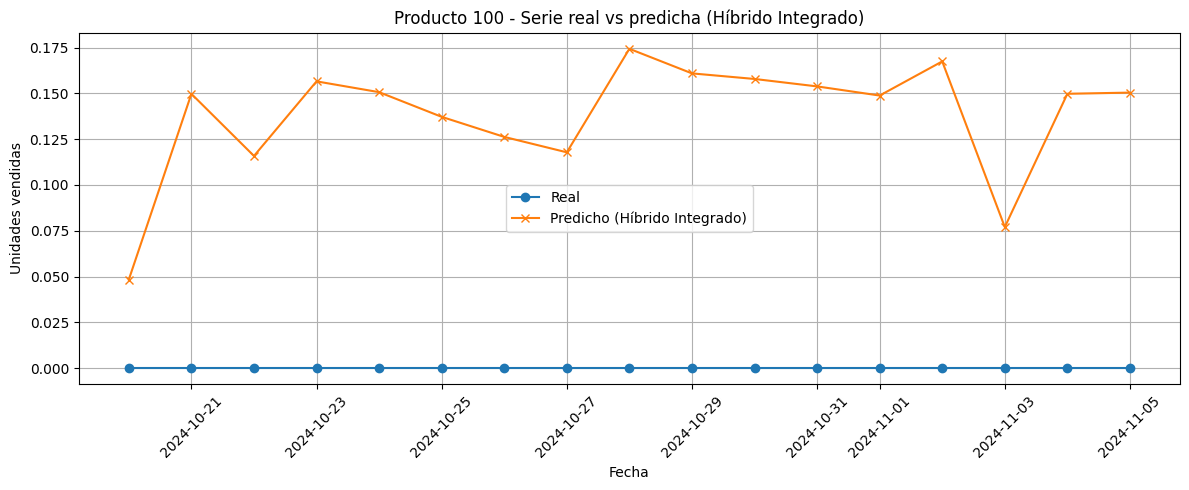

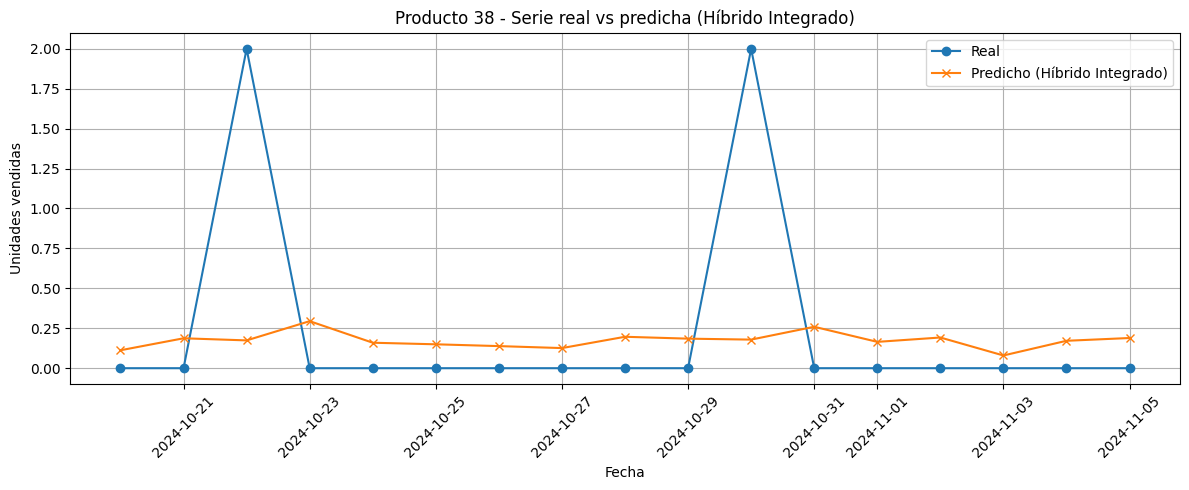

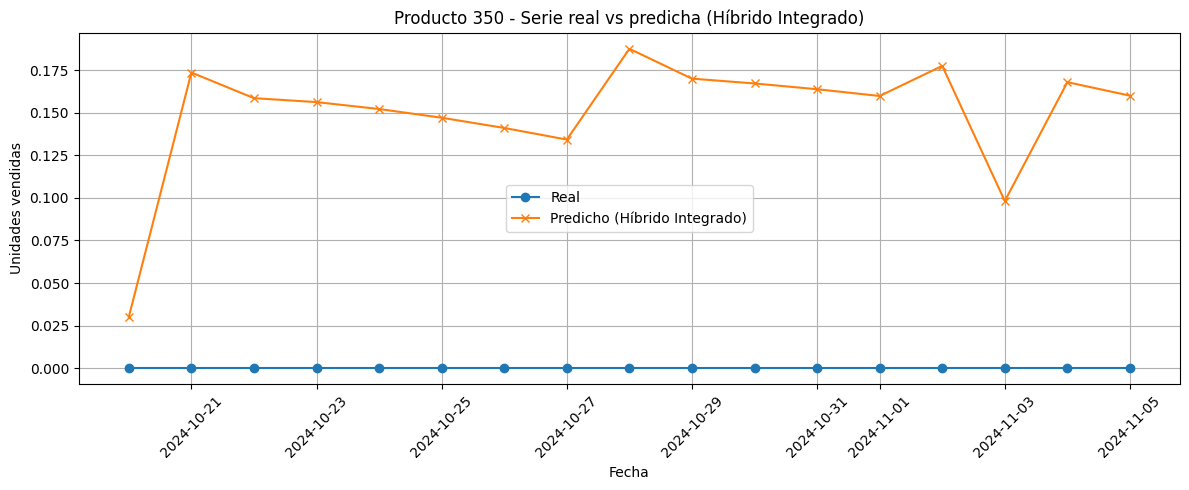

In [55]:
productos_ejemplo = [100, 38, 350] 

for producto_id in productos_ejemplo:
    df_prod = df_resultados_integrado[df_resultados_integrado['producto'] == producto_id]
    
    if df_prod.empty:
        print(f"No se encontraron datos para el producto {producto_id}")
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(df_prod['fecha'], df_prod['valor_real'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['valor_predicho'], label='Predicho (Híbrido Integrado)', marker='x')
    plt.title(f"Producto {producto_id} - Serie real vs predicha (Híbrido Integrado)")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"grafico_integrado_producto_{producto_id}.png")
    plt.show()

# 7. Modelo Naive (referencia)

In [56]:
# Cargar base
df_base = pd.read_excel("/kaggle/input/tfm-result-kmeans/base_kshape-kmeans.xlsx")
df_base = df[df["cluster_kmeans"].isin([0, 1, 3])].copy()
df_base.sort_values(by=["producto", "idSecuencia"], inplace=True)

In [57]:
resultados_arima = joblib.load("/kaggle/working/resultados_arima_292.pkl")

In [58]:
# -----------------------------
# GENERAR MODELO NAIVE
# -----------------------------
resultados_naive = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    
    if len(y_real) < 2:
        continue  # no se puede generar naive

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia")
    df_prod = df_prod.iloc[-len(y_real):].copy().reset_index(drop=True)

    fechas = df_prod["idSecuencia"].values[1:]  # desde la 2da fecha
    y_real_recortado = y_real[1:]               # valores reales desde t=2
    y_pred_naive = y_real[:-1]                  # valores anteriores como predicción

    for i in range(len(y_pred_naive)):
        resultados_naive.append({
            "producto": producto_id,
            "fecha": fechas[i],
            "valor_real": y_real_recortado[i],
            "valor_predicho": y_pred_naive[i],
            "modelo": "naive"
        })

In [59]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_naive = pd.DataFrame(resultados_naive)

# Calcular métricas por producto
metricas = df_resultados_naive.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

df_resultados_naive = df_resultados_naive.merge(metricas, on="producto", how="left")

In [60]:
df_resultados_naive.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,38,2024-10-20,0,0,naive,0.970143,0.470588,35.294118
1,38,2024-10-21,0,0,naive,0.970143,0.470588,35.294118
2,38,2024-10-22,2,0,naive,0.970143,0.470588,35.294118
3,38,2024-10-23,0,2,naive,0.970143,0.470588,35.294118
4,38,2024-10-24,0,0,naive,0.970143,0.470588,35.294118


In [61]:
# -----------------------------
# GUARDAR RESULTADOS
# -----------------------------
df_resultados_naive.to_csv("predicciones_naive.csv", index=False)
print("Predicciones del modelo naive generadas")

Predicciones del modelo naive generadas


In [62]:
# -----------------------------
# CONSTRUIR RESULTADOS ARIMA (últimos 17 puntos)
# -----------------------------
resultados_arima_list = []

for producto_id, datos_arima in resultados_arima.items():
    y_real = np.array(datos_arima["y_real"])
    y_pred = np.array(datos_arima["y_pred"])

    # Filtrar a 17 puntos
    if len(y_real) < 17:
        continue

    y_real = y_real[-17:]
    y_pred = y_pred[-17:]

    df_prod = df_base[df_base["producto"] == producto_id].copy()
    df_prod = df_prod.sort_values("idSecuencia").iloc[-len(datos_arima["y_real"]):].reset_index(drop=True)
    fechas = df_prod["idSecuencia"].values[-17:]

    for i in range(17):
        resultados_arima_list.append({
            "producto": producto_id,
            "fecha": fechas[i],
            "valor_real": y_real[i],
            "valor_predicho": y_pred[i],
            "modelo": "arima"
        })

In [63]:
# -----------------------------
# CREAR DATAFRAME Y MÉTRICAS
# -----------------------------
df_resultados_arima = pd.DataFrame(resultados_arima_list)

# Calcular métricas por producto
metricas = df_resultados_arima.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

In [64]:
# Unir métricas al resultado
df_resultados_arima = df_resultados_arima.merge(metricas, on="producto", how="left")

# -----------------------------
# GUARDAR ARCHIVO
# -----------------------------
df_resultados_arima.to_csv("resultados_arima_17.csv", index=False)
print("Resultados de ARIMA generados con 17 puntos")

Resultados de ARIMA generados con 17 puntos


In [65]:
df_resultados_arima.head()

,producto,fecha,valor_real,valor_predicho,modelo,rmse,mae,mape
0,38,2024-10-20,0,0.620471,arima,0.751769,0.711354,63.033616
1,38,2024-10-21,0,0.622834,arima,0.751769,0.711354,63.033616
2,38,2024-10-22,2,0.622692,arima,0.751769,0.711354,63.033616
3,38,2024-10-23,0,0.622701,arima,0.751769,0.711354,63.033616
4,38,2024-10-24,0,0.622700,arima,0.751769,0.711354,63.033616


# 8. Análisis de Varianza

In [66]:
# -----------------------------
# CARGAR ARCHIVOS
# -----------------------------
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_arima = pd.read_csv("/kaggle/working/resultados_arima_17.csv")
df_paralelo = pd.read_csv("/kaggle/working/predicciones_ponderado.csv")
df_secuencial = pd.read_csv("/kaggle/working/predicciones_secuencial.csv")
df_integrado = pd.read_csv("/kaggle/working/resultados_modelo_integrado.csv")
df_lstm_general = pd.read_csv("/kaggle/working/predicciones_lstm_general.csv")

In [67]:
# -----------------------------
# FILTRAR 17 ÚLTIMOS PUNTOS DE CADA MODELO
# -----------------------------
def filtrar_ultimos_17(df, nombre_modelo):
    df = df.copy()
    df = df.sort_values(["producto", "fecha"])
    df["rank"] = df.groupby("producto")["fecha"].rank(method="first", ascending=False)
    df = df[df["rank"] <= 17].copy()
    df["modelo"] = nombre_modelo
    return df.drop(columns=["rank"])

df_naive = filtrar_ultimos_17(df_naive, "naive")
df_arima = filtrar_ultimos_17(df_arima, "arima")
df_paralelo = filtrar_ultimos_17(df_paralelo, "paralelo")
df_secuencial = filtrar_ultimos_17(df_secuencial, "secuencial")
df_integrado = filtrar_ultimos_17(df_integrado, "integrado")
df_lstm_general = filtrar_ultimos_17(df_lstm_general, "lstm")

In [68]:
# Renombrar columnas en df_lstm
df_lstm_general.rename(columns={
    "valor_real": "valor_real",
    "valor_predicho": "valor_predicho",
    "metodo":"modelo"
}, inplace=True)

In [69]:
metricas_lstm = df_lstm_general.groupby("producto").apply(
    lambda df: pd.Series({
        "rmse": mean_squared_error(df["valor_real"], df["valor_predicho"], squared=False),
        "mae": mean_absolute_error(df["valor_real"], df["valor_predicho"]),
        "mape": np.mean(np.abs((df["valor_real"] - df["valor_predicho"]) / np.maximum(df["valor_real"], 1))) * 100
    }), include_groups=False
).reset_index()

In [70]:
df_lstm_general = df_lstm_general.merge(metricas_lstm, on="producto", how="left")

In [71]:
# -----------------------------
# UNIFICAR ESTRUCTURA
# -----------------------------
def estandarizar_columnas(df, nombre_modelo):
    df = df.copy()
    df["modelo"] = nombre_modelo
    columnas_requeridas = ["producto", "fecha", "valor_real", "valor_predicho", "modelo", "rmse", "mae", "mape"]
    for col in ["rmse", "mae", "mape"]:
        if col not in df.columns:
            df[col] = None  # se calcularán después si no existen
    return df[columnas_requeridas]

df_naive = estandarizar_columnas(df_naive, "naive")
df_arima = estandarizar_columnas(df_arima, "arima")
df_paralelo = estandarizar_columnas(df_paralelo, "paralelo")
df_secuencial = estandarizar_columnas(df_secuencial, "secuencial")
df_integrado = estandarizar_columnas(df_integrado, "integrado")
df_lstm_general = estandarizar_columnas(df_integrado, "lstm")

In [72]:
# -----------------------------
# UNIR TODOS LOS MODELOS
# -----------------------------
df_comparacion = pd.concat([
    df_naive,
    df_arima,
    df_paralelo,
    df_secuencial,
    df_integrado,
    df_lstm_general
], ignore_index=True)

# -----------------------------
# GUARDAR ARCHIVO FINAL
# -----------------------------
df_comparacion.to_csv("/kaggle/working/resultados_comparacion_modelos.csv", index=False)
print("Archivo unificado generado")

Archivo unificado generado


## 8.2 Verificar supuestos de ANOVA

In [74]:
# -----------------------------
# VERIFICAR NORMALIDAD POR MODELO (KOLMOGOROV-SMIRNOV)
# -----------------------------
print("Test de normalidad (Kolmogorov-Smirnov) por modelo:")
normalidad = {}
for modelo in df_comparacion["modelo"].unique():
    x = df_comparacion[df_comparacion["modelo"] == modelo]["rmse"]
    stat, p = kstest(x, "norm", args=(x.mean(), x.std()))
    normalidad[modelo] = p
    print(f" - {modelo}: p-valor = {p:.4f} {'(Normal)' if p > 0.05 else 'No normal'}")

Test de normalidad (Kolmogorov-Smirnov) por modelo:
 - naive: p-valor = 0.0000 No normal
 - arima: p-valor = 0.0000 No normal
 - paralelo: p-valor = 0.0000 No normal
 - secuencial: p-valor = 0.0000 No normal
 - integrado: p-valor = 0.0000 No normal
 - lstm: p-valor = 0.0000 No normal


In [75]:
# -----------------------------
# VERIFICAR HOMOGENEIDAD DE VARIANZAS (LEVENE)
# -----------------------------
print("Test de homogeneidad de varianzas (Levene):")
grupos_rmse = [g["rmse"].values for _, g in df_comparacion.groupby("modelo")]
stat_levene, p_levene = levene(*grupos_rmse)
print(f" - p-valor Levene = {p_levene:.4f} {'(Homogénea)' if p_levene > 0.05 else 'No homogénea'}")

Test de homogeneidad de varianzas (Levene):
 - p-valor Levene = 0.0000 No homogénea


## 8.3 Aplicar el test no parametrico Kruskal-Wallis

In [76]:
print("Prueba comparativa entre modelos:")
stat_kw, p_kw = kruskal(*grupos_rmse)
print(f" Kruskal-Wallis aplicado: p-valor = {p_kw:.4f}")

Prueba comparativa entre modelos:
 Kruskal-Wallis aplicado: p-valor = 0.0000


In [77]:
# -----------------------------
# APLICAR DUNN'S TEST POST-HOC (con corrección de Holm)
# -----------------------------
print("Prueba post-hoc de Dunn (corrección de Holm) sobre RMSE:")
dunn_result = sp.posthoc_dunn(
    df_comparacion, 
    val_col='rmse', 
    group_col='modelo', 
    p_adjust='holm'
)

print(dunn_result)

Prueba post-hoc de Dunn (corrección de Holm) sobre RMSE:
                   arima     integrado          lstm         naive  \
arima       1.000000e+00  6.570650e-03  6.570650e-03  3.365902e-35   
integrado   6.570650e-03  1.000000e+00  1.000000e+00  5.067365e-55   
lstm        6.570650e-03  1.000000e+00  1.000000e+00  5.067365e-55   
naive       3.365902e-35  5.067365e-55  5.067365e-55  1.000000e+00   
paralelo    3.473938e-05  5.594601e-01  5.594601e-01  1.827327e-64   
secuencial  1.998328e-05  2.866665e-14  2.866665e-14  2.866665e-14   

                paralelo    secuencial  
arima       3.473938e-05  1.998328e-05  
integrado   5.594601e-01  2.866665e-14  
lstm        5.594601e-01  2.866665e-14  
naive       1.827327e-64  2.866665e-14  
paralelo    1.000000e+00  3.426536e-19  
secuencial  3.426536e-19  1.000000e+00  


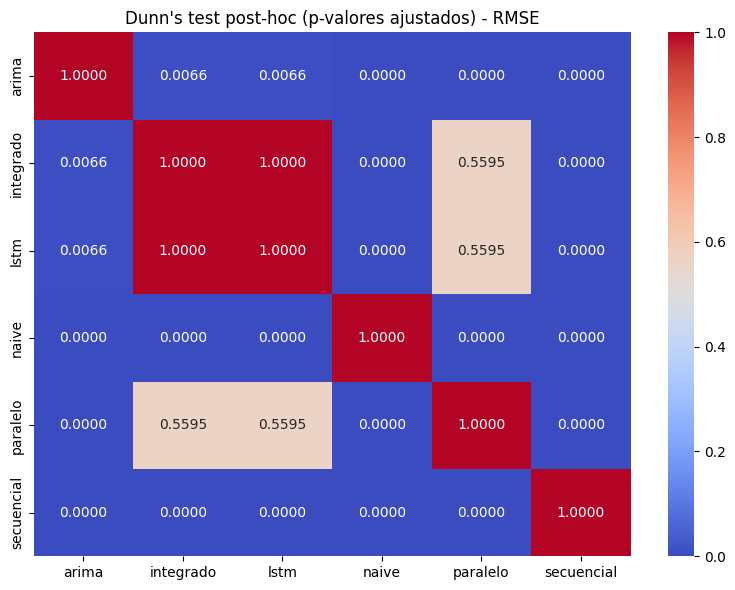

In [78]:
# -----------------------------
# VISUALIZAR MATRIZ DE P-VALORES
# -----------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".4f", cmap="coolwarm", cbar=True)
plt.title("Dunn's test post-hoc (p-valores ajustados) - RMSE")
plt.tight_layout()
plt.savefig("dunn_test_rmse_heatmap.png")
plt.show()


# 9. Mejor predicción por producto y fecha según RMSE del modelo

In [79]:
# -----------------------------
# CARGAR ARCHIVO UNIFICADO
# -----------------------------
df_comparacion = pd.read_csv("/kaggle/working/resultados_comparacion_modelos.csv")

In [80]:
# -----------------------------
# IDENTIFICAR EL MEJOR MODELO POR PRODUCTO (basado en menor RMSE)
# -----------------------------
# Obtener el modelo con menor RMSE por producto
mejores_modelos = df_comparacion.groupby("producto")["rmse"].idxmin()
df_mejores = df_comparacion.loc[mejores_modelos, ["producto", "modelo", "rmse"]].reset_index(drop=True)

# -----------------------------
# UNIR PARA TOMAR LA PREDICCIÓN COMPLETA DE ESE MODELO
# -----------------------------
df_pred_mejor = pd.merge(
    df_comparacion,
    df_mejores,
    on=["producto", "modelo", "rmse"],
    how="inner"
)[["producto", "fecha", "valor_real", "valor_predicho", "rmse", "modelo"]]

# Renombrar columna para claridad
df_pred_mejor.rename(columns={"valor_predicho": "mejor_pronostico"}, inplace=True)

In [81]:
df_pred_mejor.tail()

,producto,fecha,valor_real,mejor_pronostico,rmse,modelo
4959,998,2024-11-01,0.0,0.179656,1.329977,integrado
4960,998,2024-11-02,5.0,0.193890,1.329977,integrado
4961,998,2024-11-03,0.0,0.109087,1.329977,integrado
4962,998,2024-11-04,0.0,0.172853,1.329977,integrado
4963,998,2024-11-05,2.0,0.192438,1.329977,integrado


In [82]:
# -----------------------------
# GUARDAR RESULTADO
# -----------------------------
df_pred_mejor.to_csv("/kaggle/working/mejor_pronostico_por_producto.csv", index=False)
print("Archivo generado con las mejores predicciones por producto.")

Archivo generado con las mejores predicciones por producto.


In [83]:
# -----------------------------
# ELIMINAR DUPLICADOS POR PRODUCTO (una fila por serie)
# -----------------------------
df_modelo_unico = df_pred_mejor.drop_duplicates(subset=["producto"])

# -----------------------------
# CALCULAR FRECUENCIA PORCENTUAL POR MODELO
# -----------------------------
frecuencia = (
    df_modelo_unico["modelo"]
    .value_counts(normalize=True)
    .rename("frecuencia_porcentual")
    .reset_index()
    .rename(columns={"index": "modelo"})
)

frecuencia["frecuencia_porcentual"] = frecuencia["frecuencia_porcentual"] * 100

In [84]:
frecuencia

,modelo,frecuencia_porcentual
0,paralelo,51.369863
1,integrado,22.260274
2,naive,17.123288
3,secuencial,7.876712
4,arima,1.369863


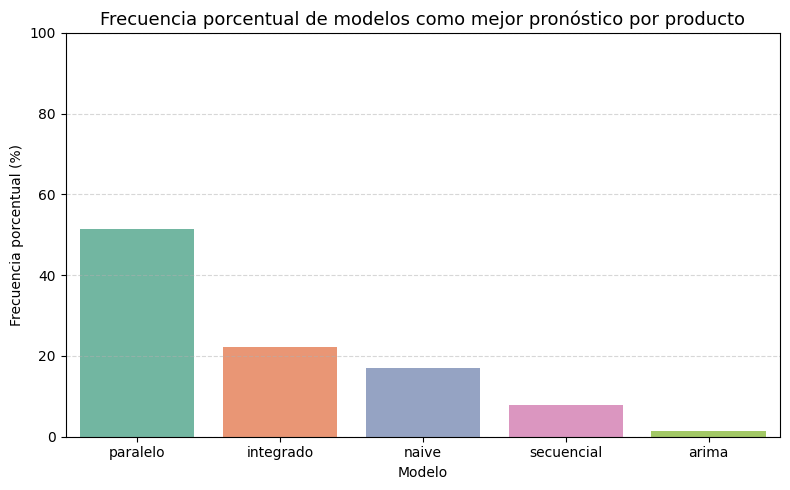

In [85]:
# -----------------------------
# GRAFICO DE BARRAS
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=frecuencia, x="modelo", y="frecuencia_porcentual", palette="Set2")
plt.title("Frecuencia porcentual de modelos como mejor pronóstico por producto", fontsize=13)
plt.ylabel("Frecuencia porcentual (%)")
plt.xlabel("Modelo")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("frecuencia_modelos_mejor_pronostico.png")
plt.show()

# 10. Impacto económico del mejor modelo

In [4]:
# -----------------------------
# Cargar archivos
# -----------------------------
df_mejor = pd.read_csv("/kaggle/working/mejor_pronostico_por_producto.csv")
df_naive = pd.read_csv("/kaggle/working/predicciones_naive.csv")
df_aprovisionamiento = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosCicloAprovisionamiento.xlsx")
df_precios = pd.read_excel("/kaggle/input/tfm-precio-y-aprov/DatosPrecioMedio.xlsx")

In [5]:
# 1. Obtener RMSE por producto del mejor modelo
resumen_mejor = df_mejor.groupby("producto").agg({
    "rmse": "mean",
    "modelo": "first"
}).reset_index()
resumen_mejor.rename(columns={"rmse": "rmse_mejor"}, inplace=True)

In [6]:
# 2. Obtener RMSE por producto del naive
rmse_naive = df_naive.groupby("producto")["rmse"].mean().reset_index()
rmse_naive.rename(columns={"rmse": "rmse_naive"}, inplace=True)

In [7]:
# 3. Calcular ciclo de aprovisionamiento
df_aprovisionamiento["aprovisionamiento"] = df_aprovisionamiento["diasEntrePedidos"] + df_aprovisionamiento["diasLeadtime"]

In [8]:
# 4. Merge de toda la información
df = pd.merge(resumen_mejor, rmse_naive, on="producto")
df = pd.merge(df, df_aprovisionamiento[["producto", "aprovisionamiento"]], on="producto")
df = pd.merge(df, df_precios[["producto", "eurPrecioMedio"]], on="producto")

In [9]:
# -----------------------------
# Cálculos de stock y económico
# -----------------------------

valor_z = 1.645  # Valor Z para 95% de confianza
porcentaje_coste = 0.05  # 5% de coste de mantenimiento

# Stock en unidades
df["udsStock_naive"] = valor_z * df["rmse_naive"] * np.sqrt(df["aprovisionamiento"])
df["udsStock_mejor"] = valor_z * df["rmse_mejor"] * np.sqrt(df["aprovisionamiento"])

# Coste del stock (5% del valor)
df["coste_udsStock_naive"] = df["udsStock_naive"] * df["eurPrecioMedio"] * porcentaje_coste
df["coste_udsStock_mejor"] = df["udsStock_mejor"] * df["eurPrecioMedio"] * porcentaje_coste

# Coste anual 
df["coste_anual_naive"] = df["coste_udsStock_naive"] * 365
df["coste_anual_mejor"] = df["coste_udsStock_mejor"] * 365

# Ahorro
df["ahorro_unidades"] = df["udsStock_naive"] - df["udsStock_mejor"]
df["ahorro_coste_stock"] = df["coste_anual_naive"] - df["coste_anual_mejor"]

In [10]:
df.head()

,producto,rmse_mejor,modelo,rmse_naive,aprovisionamiento,eurPrecioMedio,udsStock_naive,udsStock_mejor,coste_udsStock_naive,coste_udsStock_mejor,coste_anual_naive,coste_anual_mejor,ahorro_unidades,ahorro_coste_stock
0,38,0.648216,integrado,0.970143,29,115.700000,8.594101,5.742286,49.716872,33.219124,18146.658218,12124.980335,2.851815,6021.677883
1,52,2.748096,paralelo,3.678235,29,24.503333,32.583997,24.344275,39.920827,29.825794,14571.101901,10886.414956,8.239722,3684.686945
2,95,0.472177,integrado,0.685994,29,73.010000,6.076947,4.182825,22.183894,15.269403,8097.121411,5573.332270,1.894122,2523.789141
3,100,0.000000,naive,0.000000,29,147.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,104,2.113769,paralelo,3.199265,29,39.980000,28.340993,18.725026,56.653645,37.431327,20678.580517,13662.434350,9.615967,7016.146167


In [11]:
# -----------------------------
# Resultados agregados
# -----------------------------
total_coste_naive = df["coste_anual_naive"].sum()
total_coste_mejor = df["coste_anual_mejor"].sum()
total_ahorro = df["ahorro_coste_stock"].sum()
porcentaje_ahorro = 100 * total_ahorro / df["coste_anual_naive"].sum()

print(f"Coste total de stock naive: {total_coste_naive:.2f} €")
print(f"Coste total de stock mejor: {total_coste_mejor:.2f} €")
print(f"Ahorro económico anual estimado: {total_ahorro:.2f} €")
print(f"Porcentaje de ahorro respecto al Naive: {porcentaje_ahorro:.2f}%")

Coste total de stock naive: 2560797.28 €
Coste total de stock mejor: 1755079.33 €
Ahorro económico anual estimado: 805717.95 €
Porcentaje de ahorro respecto al Naive: 31.46%


In [12]:
# -----------------------------
# Guardar resumen
# -----------------------------
df.to_csv("impacto_economico.csv", index=False)
print("Archivo generado.")

Archivo generado.


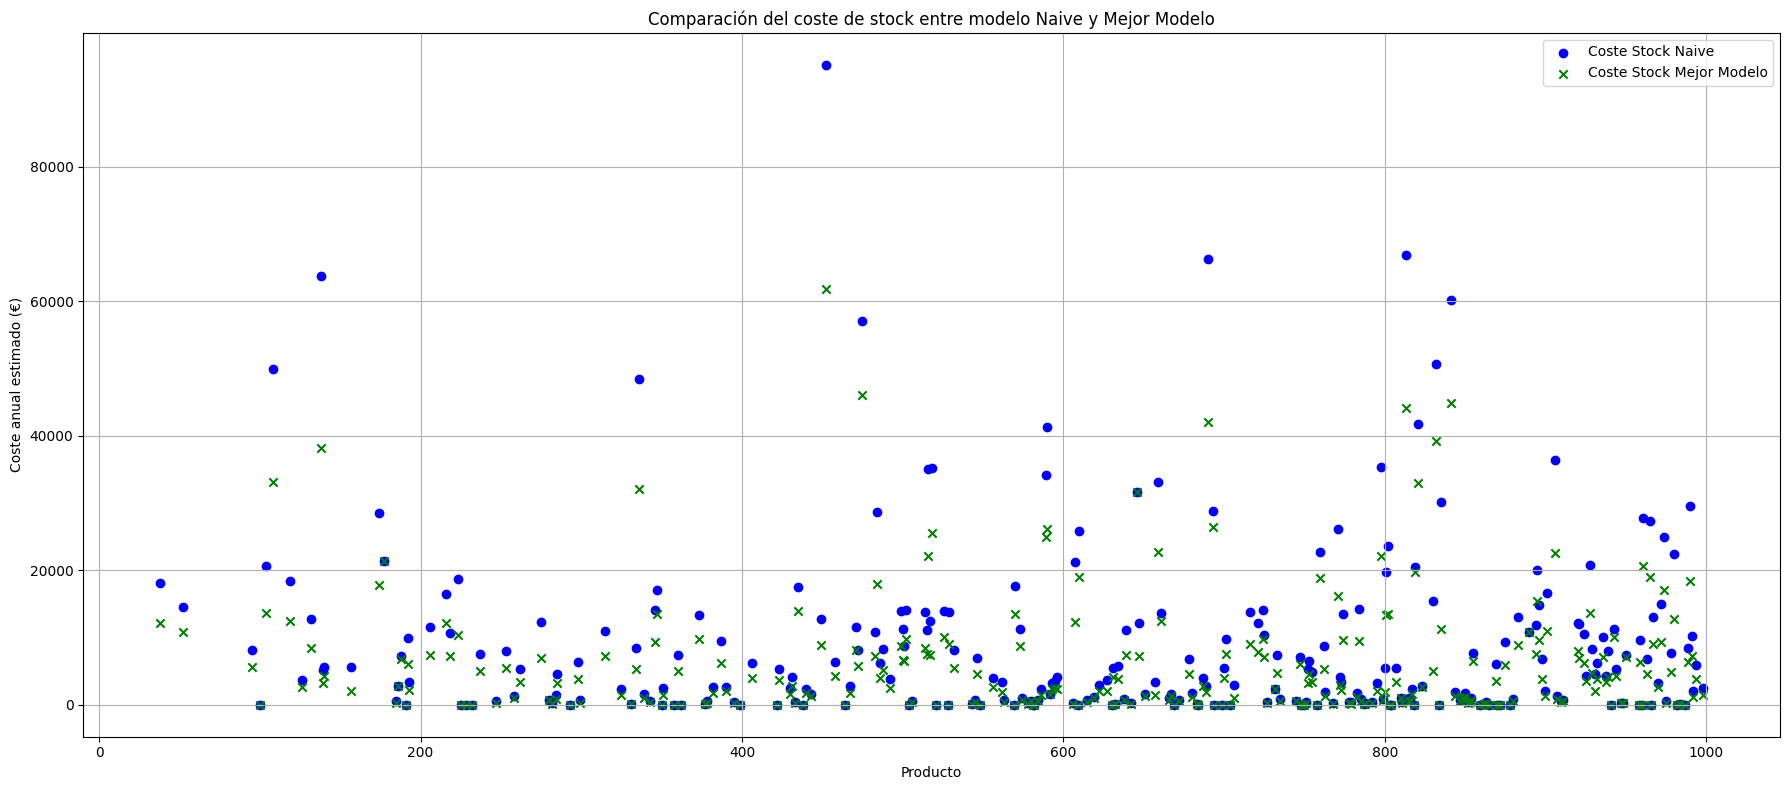

In [13]:
# -----------------------------
# Ordenar productos para el gráfico
# -----------------------------
df_sorted = df.sort_values("producto").reset_index(drop=True)

# -----------------------------
# Graficar coste_stock naive vs mejor
# -----------------------------
plt.figure(figsize=(18, 8))

# Scatter para Naive
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_naive'], label='Coste Stock Naive', marker='o', color='blue')

# Scatter para Mejor Modelo
plt.scatter(df_sorted['producto'], df_sorted['coste_anual_mejor'], label='Coste Stock Mejor Modelo', marker='x', color='green')

plt.title("Comparación del coste de stock entre modelo Naive y Mejor Modelo")
plt.xlabel("Producto")
plt.ylabel("Coste anual estimado (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lineplot_coste_stock_comparativo.png")
plt.show()